In [26]:
# Month 2 Week 4 — SQL for Finance and the Full Fintech Pipeline

In [27]:
#Create a SQLite database and a table to store OHLCV price data:
import sqlite3
import pandas as pd
import numpy as np

# Create database file (creates it if it doesn't exist)
conn = sqlite3.connect("market_data.db")
cursor = conn.cursor()

# Create a table for daily price bars
cursor.execute("""
    CREATE TABLE IF NOT EXISTS price_bars (
        id        INTEGER PRIMARY KEY AUTOINCREMENT,
        ticker    TEXT NOT NULL,
        date      TEXT NOT NULL,
        open      REAL,
        high      REAL,
        low       REAL,
        close     REAL,
        volume    INTEGER,
        UNIQUE(ticker, date)   -- no duplicate rows per ticker/date
    )
""")

conn.commit()
print("Database created: market_data.db")
print("Table 'price_bars' ready")

Database created: market_data.db
Table 'price_bars' ready


In [28]:
#Insert data and query it with SQL
import yfinance as yf

# Download data for 3 tickers
tickers = ["SPY","QQQ","GLD"]
for ticker in tickers:
    df = yf.download(ticker, period="2y")
    df.columns = df.columns.get_level_values(0)
    df = df.reset_index()
    df["ticker"] = ticker
    df["date"]   = df["Date"].astype(str)

    for _, row in df.iterrows():
        cursor.execute("""
            INSERT OR IGNORE INTO price_bars
            (ticker, date, open, high, low, close, volume)
            VALUES (?, ?, ?, ?, ?, ?, ?)
        """, (row["ticker"], row["date"],
              row["Open"], row["High"], row["Low"],
              row["Close"], row["Volume"]))

conn.commit()
print("Data inserted successfully")

# COUNT: how many rows per ticker?
result = pd.read_sql("""
    SELECT ticker, COUNT(*) as days
    FROM price_bars
    GROUP BY ticker
""", conn)
print(result)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Data inserted successfully
  ticker  days
0    GLD   501
1    QQQ   501
2    SPY   501


In [29]:
#Core sql queries
# 1. SELECT — fetch all SPY data sorted by date
spy = pd.read_sql("""
    SELECT date, open, high, low, close, volume
    FROM price_bars
    WHERE ticker = 'SPY'
    ORDER BY date DESC
    LIMIT 5
""", conn)
print("--- Latest 5 SPY bars ---")
print(spy.to_string(index=False))

# 2. WHERE with conditions — find big move days
big_moves = pd.read_sql("""
    SELECT ticker, date, close,
           ROUND((close - open) / open * 100, 2) as day_return_pct
    FROM price_bars
    WHERE ABS((close - open) / open) > 0.01
    ORDER BY ABS((close - open) / open) DESC
    LIMIT 10
""", conn)
print("\n--- Biggest single-day moves (>1%) ---")
print(big_moves.to_string(index=False))

# 3. GROUP BY — average volume per ticker
avg_vol = pd.read_sql("""
    SELECT ticker,
           ROUND(AVG(volume)) as avg_daily_volume,
           ROUND(AVG(close), 2) as avg_close
    FROM price_bars
    GROUP BY ticker
    ORDER BY avg_daily_volume DESC
""", conn)
print("\n--- Average daily volume by ticker ---")
print(avg_vol.to_string(index=False))

--- Latest 5 SPY bars ---
      date       open       high        low      close   volume
2026-06-09        NaN        NaN        NaN        NaN 86844734
2026-06-08 743.359985 745.340027 738.190002 739.219971 49213400
2026-06-05 752.309998 752.820007 735.530029 737.549988 93989400
2026-06-04 752.099976 758.309998 751.469971 757.090027 49923000
2026-06-03 758.150024 758.799988 753.570007 754.239990 51402500

--- Biggest single-day moves (>1%) ---
ticker       date      close  day_return_pct
   QQQ 2025-04-09 463.755249           12.14
   SPY 2025-04-09 542.402222           11.18
   QQQ 2025-04-08 414.055786           -5.04
   SPY 2025-04-08 490.853119           -4.86
   GLD 2026-01-30 444.950012           -4.57
   QQQ 2025-11-20 585.820000           -4.22
   QQQ 2025-04-07 421.649078            3.68
   QQQ 2025-10-10 589.620000           -3.56
   QQQ 2025-04-04 420.633972           -3.53
   SPY 2025-04-04 499.553345           -3.51

--- Average daily volume by ticker ---
ticker  avg_dai

In [30]:
#Compute signals directly in SQL
# Moving average crossover signal computed in SQL
signals = pd.read_sql("""
    SELECT
        ticker,
        date,
        close,
        AVG(close) OVER (
            PARTITION BY ticker
            ORDER BY date
            ROWS BETWEEN 49 PRECEDING AND CURRENT ROW
        ) as ma50,
        AVG(close) OVER (
            PARTITION BY ticker
            ORDER BY date
            ROWS BETWEEN 199 PRECEDING AND CURRENT ROW
        ) as ma200
    FROM price_bars
    WHERE ticker = 'SPY'
    ORDER BY date
""", conn)

# Add signal column in Python
signals["signal"] = (signals["ma50"] > signals["ma200"]).astype(int)
signals = signals.dropna()

print(f"Days with signal=1 (in market): {signals['signal'].sum()}")
print(f"Days with signal=0 (in cash):   {(signals['signal']==0).sum()}")
print("\nLatest signals:")
print(signals[["date","close","ma50","ma200","signal"]].tail(6).to_string(index=False))

Days with signal=1 (in market): 401
Days with signal=0 (in cash):   99

Latest signals:
      date      close       ma50      ma200  signal
2026-06-01 758.539978 705.621801 681.011915       1
2026-06-02 759.570007 707.841801 681.585265       1
2026-06-03 754.239990 709.819000 682.138865       1
2026-06-04 757.090027 711.897201 682.708266       1
2026-06-05 737.549988 713.511801 683.197265       1
2026-06-08 739.219971 715.394399 683.703765       1


In [31]:
#Store strategy results back to the database
# Compute full strategy results
signals["returns"]  = signals["close"].pct_change()
signals["strategy"] = signals["returns"] * signals["signal"].shift(1)
signals["equity_strategy"] = (1 + signals["strategy"].fillna(0)).cumprod() #compounded porfolio value starting from $1
signals["equity_bh"]       = (1 + signals["returns"].fillna(0)).cumprod()

# Create results table
cursor.execute("""
    CREATE TABLE IF NOT EXISTS strategy_results (
        ticker   TEXT,
        date     TEXT,
        signal   INTEGER,
        returns  REAL,
        strategy REAL,
        equity   REAL,
        PRIMARY KEY (ticker, date)
    )
""")

# Insert results
for _, row in signals.iterrows(): #loops through each row of the DataFrame one at a time
    cursor.execute("""
        INSERT OR REPLACE INTO strategy_results
        VALUES (?, ?, ?, ?, ?, ?)
    """, ("SPY", row["date"], int(row["signal"]),
          row["returns"], row["strategy"], row["equity_strategy"]))

conn.commit()

# Verify
stored = pd.read_sql("""
    SELECT COUNT(*) as rows,
           ROUND(MAX(equity),4) as peak_equity,
           ROUND(MIN(equity),4) as trough_equity
    FROM strategy_results
    WHERE ticker = 'SPY'
""", conn)
print("Strategy results stored:")
print(stored.to_string(index=False))

Strategy results stored:
 rows  peak_equity  trough_equity
  500       1.1693          0.894


In [32]:
#Query stored results
# Query stored results for performance summary
perf = pd.read_sql("""
    SELECT
        ticker,
        COUNT(*)                              as trading_days,
        ROUND(MAX(equity) - 1, 4)            as peak_return,
        ROUND(MIN(equity) - 1, 4)            as trough_return,
        ROUND(AVG(strategy) * 252, 4)        as ann_return,
        ROUND(AVG(CASE WHEN signal=1
              THEN 1.0 ELSE 0 END), 2)       as pct_time_invested
    FROM strategy_results
    GROUP BY ticker
""", conn)

print("Strategy performance from database:")
print(perf.to_string(index=False))

Strategy performance from database:
ticker  trading_days  peak_return  trough_return  ann_return  pct_time_invested
   SPY           500       0.1693         -0.106      0.0768                0.8


In [33]:
#Build the complete end-to-end pipeline
#fetch live data, store it, compute signals, generate report:
import sqlite3, requests, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ── CONFIG ──────────────────────────────────────────────
API_KEY    = ""
SECRET_KEY = ""
TICKERS    = ["SPY", "QQQ", "GLD"]
DAYS       = 365

# ── STEP 1: DATABASE SETUP ───────────────────────────────
conn   = sqlite3.connect("market_data.db")
cursor = conn.cursor()
cursor.execute("""
    CREATE TABLE IF NOT EXISTS price_bars (
        ticker TEXT, date TEXT, open REAL,
        high REAL, low REAL, close REAL, volume INTEGER,
        UNIQUE(ticker, date))""")
conn.commit()

# ── STEP 2: FETCH FROM API ───────────────────────────────
headers  = {"APCA-API-KEY-ID": API_KEY,
            "APCA-API-SECRET-KEY": SECRET_KEY}
end   = datetime.now().strftime("%Y-%m-%dT%H:%M:%SZ")
start = (datetime.now()-timedelta(days=DAYS)).strftime("%Y-%m-%dT%H:%M:%SZ")

for ticker in TICKERS:
    resp = requests.get(
        f"https://data.alpaca.markets/v2/stocks/{ticker}/bars",
        headers=headers,
        params={"timeframe":"1Day","start":start,
                "end":end,"limit":2000,"feed":"iex"})

    if resp.status_code != 200:
        print(f"Error fetching {ticker}: {resp.status_code}")
        continue

    bars = pd.DataFrame(resp.json().get("bars",[]))
    if bars.empty:
        print(f"No data for {ticker}")
        continue

    bars["t"] = pd.to_datetime(bars["t"]).dt.strftime("%Y-%m-%d")
    for _, row in bars.iterrows():
        cursor.execute("""
            INSERT OR IGNORE INTO price_bars
            (ticker, date, open, high, low, close, volume)
            VALUES (?,?,?,?,?,?,?)""",
            (ticker, row["t"], row["o"], row["h"],
             row["l"], row["c"], row["v"]))

conn.commit()
print(f"Data stored for: {TICKERS}")

# ── STEP 3: COMPUTE SIGNALS & PERFORMANCE ────────────────
results = {}
for ticker in TICKERS:
    df = pd.read_sql(f"""
        SELECT date, close FROM price_bars
        WHERE ticker='{ticker}' ORDER BY date
    """, conn)
    df["close"]    = df["close"].astype(float)
    df["ma50"]     = df["close"].rolling(50).mean()
    df["ma200"]    = df["close"].rolling(200).mean()
    df["signal"]   = (df["ma50"] > df["ma200"]).astype(int)
    df["returns"]  = df["close"].pct_change()
    df["strategy"] = df["returns"] * df["signal"].shift(1)
    df = df.dropna()

    total  = (1+df["strategy"]).cumprod().iloc[-1]-1
    bh     = (1+df["returns"]).cumprod().iloc[-1]-1
    sharpe = ((df["strategy"].mean()-0.045/252)*252 /
               (df["strategy"].std()*np.sqrt(252)))
    dd     = ((1+df["strategy"]).cumprod() /
               (1+df["strategy"]).cumprod().cummax()-1).min()

    results[ticker] = {
        "Strategy": f"{total*100:.1f}%",
        "BuyHold":  f"{bh*100:.1f}%",
        "Sharpe":   f"{sharpe:.2f}",
        "MaxDD":    f"{dd*100:.1f}%"
    }

print("\n── Performance Report ──────────────────")
print(pd.DataFrame(results).T.to_string())

Data stored for: ['SPY', 'QQQ', 'GLD']

── Performance Report ──────────────────
    Strategy BuyHold Sharpe   MaxDD
SPY    11.4%   31.5%   0.35  -12.4%
QQQ    27.9%   48.5%   0.88  -13.6%
GLD    40.9%   42.8%   1.04  -20.1%


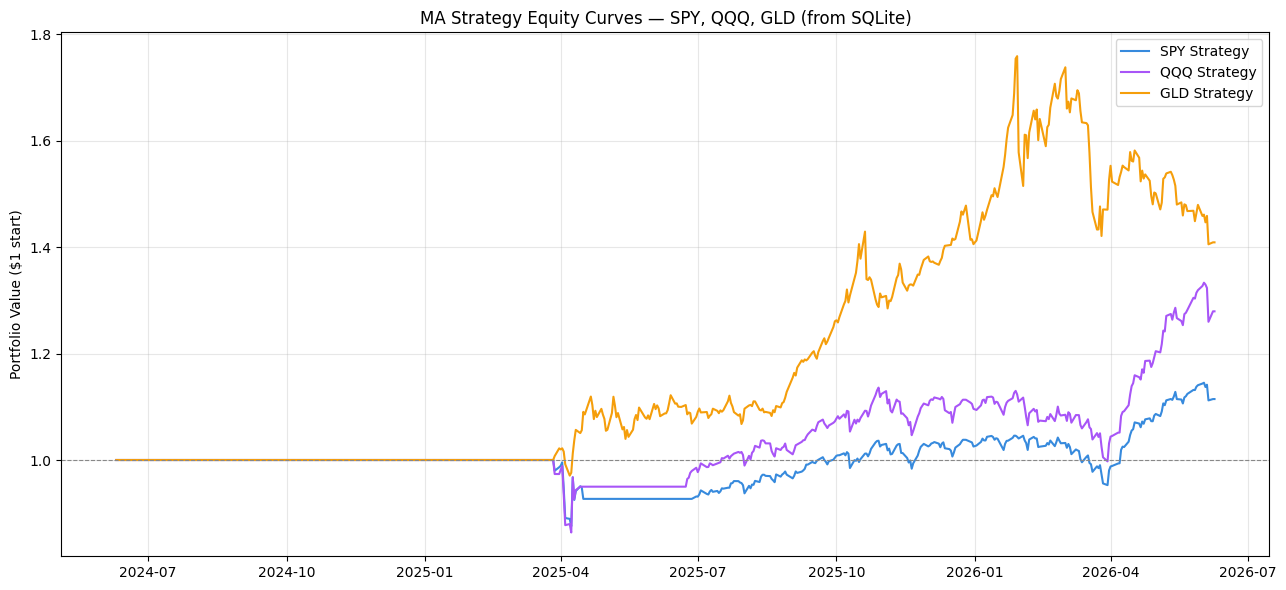

Pipeline complete. Database closed.


In [34]:
#Plot equity curves for all tickers from the database
fig, ax = plt.subplots(figsize=(13, 6))
colors = {"SPY":"#378ADD","QQQ":"#A855F7","GLD":"#F59E0B"}

for ticker in TICKERS:
    df = pd.read_sql(f"""
        SELECT date, close FROM price_bars
        WHERE ticker='{ticker}' ORDER BY date
    """, conn)
    df["close"]    = df["close"].astype(float)
    df["ma50"]     = df["close"].rolling(50).mean()
    df["ma200"]    = df["close"].rolling(200).mean()
    df["signal"]   = (df["ma50"]>df["ma200"]).astype(int)
    df["returns"]  = df["close"].pct_change()
    df["strategy"] = df["returns"]*df["signal"].shift(1)
    df["equity"]   = (1+df["strategy"].fillna(0)).cumprod()
    df["date"]     = pd.to_datetime(df["date"])

    ax.plot(df["date"], df["equity"],
            color=colors[ticker], linewidth=1.5, label=f"{ticker} Strategy")

ax.axhline(1, color="#888", linewidth=0.8, linestyle="--")
ax.set_title("MA Strategy Equity Curves — SPY, QQQ, GLD (from SQLite)")
ax.set_ylabel("Portfolio Value ($1 start)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

conn.close()
print("Pipeline complete. Database closed.")

1. Asset class matters as much as strategy design. The same MA crossover returned +75% on GLD and +13% on SPY over the same period — not because the strategy worked better on gold, but because gold was in a stronger trend. Strategy performance is inseparable from market regime.
2. GLD's drawdown from peak illustrates the exit lag problem. A 1.75 peak dropping to 1.40 is a -20% drawdown from the top. The strategy is still invested. A faster signal (shorter MAs) would have exited earlier but would also have generated more false signals during the choppy 2025 period.
3. The flat entry period for SPY and QQQ is a real cost. They sat in cash from mid-2024 to April 2025 — nearly a year — while the market was already recovering. That missed rally is the price of using a slow 200-day MA.